## Title : ScreenSense:Kids’ Screentime Visualization
### Project Statement 
Analyze kids’ screentime patterns to uncover trends by age, gender, location type 
(urban/rural), device type, day-of-week, and activity category using data visualization. The 
goal is to present clear, actionable insights for parents, educators, and policymakers.  
### Expected Outcomes 
- Understand and preprocess the screentime dataset for analysis
- Explore trends across weekdays/weekends, devices, and activities 
- Visualize key metrics using bar charts, distributions, heatmaps, and comparisons 
- Summarize insights for non-technical stakeholders via a visual report/dashboard 
- Provide a final presentation with the key findings and visuals

### WEEK - 1

**Importing Libraries**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Load Dataset**

In [6]:
df = pd.read_csv('Indian_Kids_Screen_Time.csv')
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


**Basic Checks**

In [8]:
df.columns.tolist()

['Age',
 'Gender',
 'Avg_Daily_Screen_Time_hr',
 'Primary_Device',
 'Exceeded_Recommended_Limit',
 'Educational_to_Recreational_Ratio',
 'Health_Impacts',
 'Urban_or_Rural']

In [9]:
df.shape

(9712, 8)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [11]:
df.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

In [12]:
df.isnull().sum() / len(df) * 100

Age                                   0.000000
Gender                                0.000000
Avg_Daily_Screen_Time_hr              0.000000
Primary_Device                        0.000000
Exceeded_Recommended_Limit            0.000000
Educational_to_Recreational_Ratio     0.000000
Health_Impacts                       33.134267
Urban_or_Rural                        0.000000
dtype: float64

In [13]:
df['Exceeded_Recommended_Limit'].value_counts()

Exceeded_Recommended_Limit
True     8301
False    1411
Name: count, dtype: int64

In [14]:
df['Health_Impacts'] = df['Health_Impacts'].fillna('No Health Impact')

In [15]:
df.isnull().sum()

Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64

In [16]:
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [17]:
df.describe(include='O')

,Gender,Primary_Device,Health_Impacts,Urban_or_Rural
count,9712,9712,9712,9712
unique,2,4,16,2
top,Male,Smartphone,No Health Impact,Urban
freq,4942,4568,3218,6851


In [18]:
df.Health_Impacts.unique()

array(['Poor Sleep, Eye Strain', 'Poor Sleep', 'No Health Impact',
       'Poor Sleep, Anxiety', 'Poor Sleep, Obesity Risk', 'Eye Strain',
       'Obesity Risk', 'Anxiety', 'Poor Sleep, Anxiety, Obesity Risk',
       'Eye Strain, Obesity Risk', 'Eye Strain, Anxiety, Obesity Risk',
       'Anxiety, Obesity Risk', 'Poor Sleep, Eye Strain, Obesity Risk',
       'Poor Sleep, Eye Strain, Anxiety',
       'Poor Sleep, Eye Strain, Anxiety, Obesity Risk',
       'Eye Strain, Anxiety'], dtype=object)

In [19]:
df.duplicated().sum()

44

In [20]:
# we have to remove duplicates
df = df.drop_duplicates()
df.shape

(9668, 8)

In [21]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,No Health Impact,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


## WEEK-2

### **EDA - Exploratory Data Analysis**

**Age Derivates**

In [25]:
df['Age'].describe()
df['Age'].value_counts().sort_index()

Age
8     900
9     875
10    863
11    863
12    867
13    910
14    895
15    864
16    874
17    918
18    839
Name: count, dtype: int64

In [26]:
df['Age_Band'] = pd.cut(
    df['Age'],
    bins=[8,10,13,16,18],
    labels=['Kids', 'Pre-Teen', 'Teen', 'Late Teen'],
    include_lowest=True
)
# labels=['8-10 (Kids)', '11-13 (Pre-Teen)', '14-16 (Teen)', '17-18 (Late Teen)'],

In [27]:
df['Age_Band'].value_counts().sort_index()

Age_Band
Kids         2638
Pre-Teen     2640
Teen         2633
Late Teen    1757
Name: count, dtype: int64

**Insight:**
The dataset is almost evenly distributed across Kids, Pre-Teens, and Teens (about 27% each), while Late Teens make up a smaller portion (about 18%). This means the data mainly represents children between 8 and 16 years old.

**Device Access Type**

In [30]:
df['Primary_Device'].value_counts()

Primary_Device
Smartphone    4540
TV            2478
Laptop        1431
Tablet        1219
Name: count, dtype: int64

In [31]:
df['Primary_Device'] = df['Primary_Device'].str.strip().str.lower()
personal_devices = ['smartphone','tablet','laptop']
df['Device_Access_Type'] = df['Primary_Device'].apply(
    lambda x: 'Personal Device' if x in personal_devices else 'Shared Device')

In [32]:
df['Device_Access_Type'].value_counts()

Device_Access_Type
Personal Device    7190
Shared Device      2478
Name: count, dtype: int64

**Insight:**
Around 74% of children are using their own personal devices like smartphones, tablets, or laptops instead of shared family devices. This shows that most kids are using screens independently, which may lead to less parental supervision and higher chances of spending more time on recreational or risky screen activities.

**Educational vs Recreational Usage Share**

In [35]:
df['Educational_to_Recreational_Ratio'].describe()

count    9668.000000
mean        0.427028
std         0.073185
min         0.300000
25%         0.370000
50%         0.430000
75%         0.480000
max         0.600000
Name: Educational_to_Recreational_Ratio, dtype: float64

In [36]:
median_ratio = df['Educational_to_Recreational_Ratio'].median()

df['Usage_Purpose_Type'] = df['Educational_to_Recreational_Ratio'].apply(
    lambda x: 'Education Dominant' if x >= median_ratio else 'Recreation Dominant'
)

In [37]:
df['Usage_Purpose_Type'].value_counts()

Usage_Purpose_Type
Education Dominant     4902
Recreation Dominant    4766
Name: count, dtype: int64

**Insights:**
About half of the children use screens more for education, while the other half use them more for entertainment.

**Derivate of Health Impact Flag**

In [40]:
df['Health_Impact_Flag'] = df['Health_Impacts'].apply(
    lambda x: 0 if x == 'No Health Impact' else 1
)

**Derivate of Screen Time Level**

In [42]:
df['Avg_Daily_Screen_Time_hr'].value_counts()

Avg_Daily_Screen_Time_hr
0.00     194
4.93      40
4.96      39
4.32      39
4.03      39
        ... 
9.68       1
8.22       1
8.06       1
10.07      1
7.47       1
Name: count, Length: 899, dtype: int64

In [43]:
df['Screen_Time_Level'] = pd.cut(
    df['Avg_Daily_Screen_Time_hr'],
    bins=[-0.01,2,4,6,14],
    labels=['Low','Moderate','High','Very High']
)

In [44]:
df['Screen_Time_Level'].isna().sum()

0

**insight:**
* Most children in the dataset have high daily screen time (4–6 hours), and only a few have low screen time.<br>
**Screen_Time_Level**<br>
Low -> (<2h)<br>
Moderate -> (2–4h) <br>
High -> (4–6h)  <br>
Very High -> (>6h)  <br>

**Engagement Risk Level**

In [47]:
df['Engagement_Risk_Level'] = df.apply(
    lambda row: 'High Risk' if row['Avg_Daily_Screen_Time_hr'] > 6 and row['Educational_to_Recreational_Ratio'] < median_ratio
    else 'Moderate Risk' if row['Avg_Daily_Screen_Time_hr'] > 4
    else 'Low Risk',
    axis=1
)

In [48]:
df['Engagement_Risk_Level'].value_counts().sort_index()

Engagement_Risk_Level
High Risk         548
Low Risk         3725
Moderate Risk    5395
Name: count, dtype: int64

In [49]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Device_Access_Type,Usage_Purpose_Type,Health_Impact_Flag,Screen_Time_Level,Engagement_Risk_Level
0,14,Male,3.99,smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teen,Personal Device,Recreation Dominant,1,Moderate,Low Risk
1,11,Female,4.61,laptop,True,0.30,Poor Sleep,Urban,Pre-Teen,Personal Device,Recreation Dominant,1,High,Moderate Risk
2,18,Female,3.73,tv,True,0.32,Poor Sleep,Urban,Late Teen,Shared Device,Recreation Dominant,1,Moderate,Low Risk
3,15,Female,1.21,laptop,False,0.39,No Health Impact,Urban,Teen,Personal Device,Recreation Dominant,0,Low,Low Risk
4,12,Female,5.89,smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Pre-Teen,Personal Device,Education Dominant,1,High,Moderate Risk


In [50]:
df.to_csv("Processed_Kids_Screen_Time.csv", index=False)

**Delivarables**
| Feature               | Description                                                |
| --------------------- | ---------------------------------------------------------- |
| Age_Band              | Age group classification                                   |
| Screen_Time_Level     | Daily usage intensity                                      |
| Usage_Purpose_Type    | Education or Recreation dominant usage                     |
| Device_Access_Type    | Personal or Shared device usage                            |
| Health_Impact_Flag    | Presence of health issues (1/0)                            |
| Engagement_Risk_Level | Risk level based on screen time and recreational dominance |

- Handled missing values in Health_Impacts
- Removed duplicate records
- Standardized Primary_Device column
- Educational vs Recreational usage classified using median-based threshold

## WEEK-3

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("talk")  
plt.rcParams['figure.figsize'] = (10,6)

**Daily Hours Distribution**

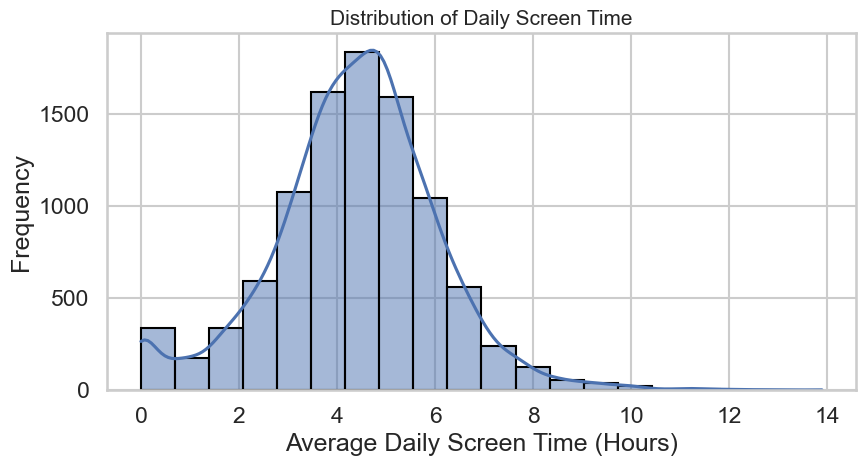

In [55]:
sns.set_style("whitegrid")
plt.figure(figsize=(9,5))

sns.histplot(
    df["Avg_Daily_Screen_Time_hr"],
    bins=20,
    kde=True,
    color="#4C72B0",
    edgecolor="black"
)

plt.title("Distribution of Daily Screen Time", fontsize=15)
plt.xlabel("Average Daily Screen Time (Hours)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Insights:**
- Most kids are spending around 4 to 6 hours per day.
- Very few kids are below 2 hours.<br>
**That means:**<br>
The distribution of daily screen time is slightly right-skewed, indicating that while most children fall within moderate usage levels, a smaller group of heavy users significantly increases the overall average.

**Age Band Distribution**

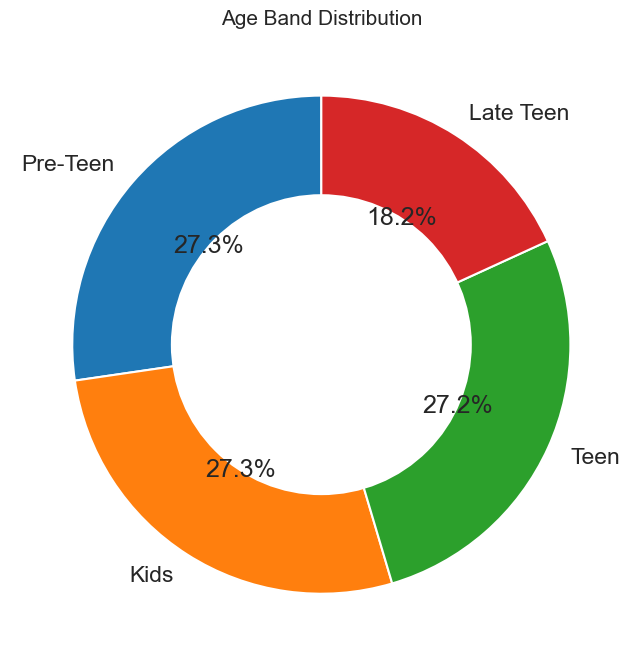

In [58]:
plt.figure(figsize=(7,7))
age_counts = df["Age_Band"].value_counts()
plt.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor":"white"})
plt.gca().add_artist(plt.Circle((0,0),0.6,fc="white"))  # donut effect
plt.title("Age Band Distribution", fontsize=15)
plt.tight_layout(); plt.show()

**Insight:**
- The dataset is fairly balanced across Kids, Pre-Teen, and Teen categories.
- Late Teens form a comparatively smaller portion.
- This ensures that behavioural analysis is not biased toward a specific age group.

**Device Usage Distribution**

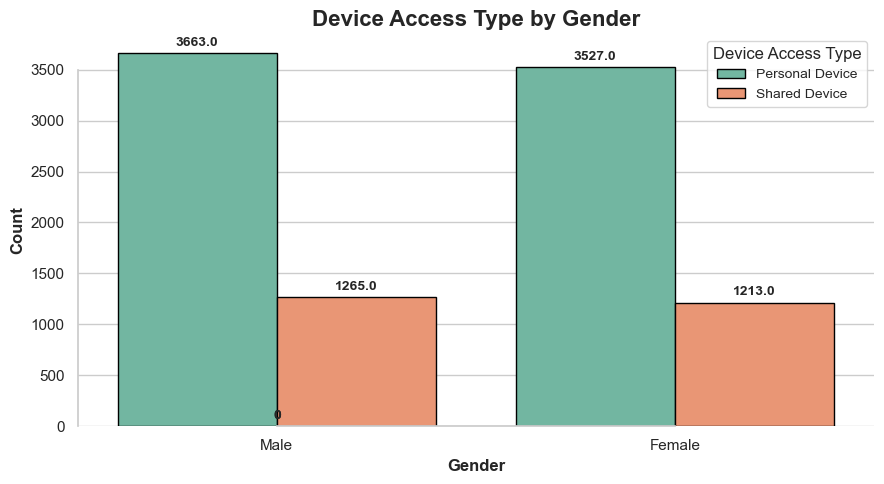

In [61]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9,5))
ax = sns.countplot(data=df, x="Gender", hue="Device_Access_Type", palette="Set2", edgecolor='black', linewidth=1)
for p in ax.patches: ax.annotate(f'{p.get_height()}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=10, weight='bold', xytext=(0,3), textcoords='offset points')
plt.title("Device Access Type by Gender", fontsize=16, weight='bold'); plt.xlabel("Gender", fontsize=12, weight='bold'); plt.ylabel("Count", fontsize=12, weight='bold')
plt.legend(title="Device Access Type", title_fontsize=12, fontsize=10); sns.despine(trim=True)
plt.tight_layout(); plt.show()

**Insights:**
- Most children are using personal devices.<br>
**This means:**<br>
- They have independent access, which can lead to more screen time because there is less restriction.
- Individual ownership may lead to reduced parental monitoring and increased recreational usage patterns.

**Screen Time by Gender**

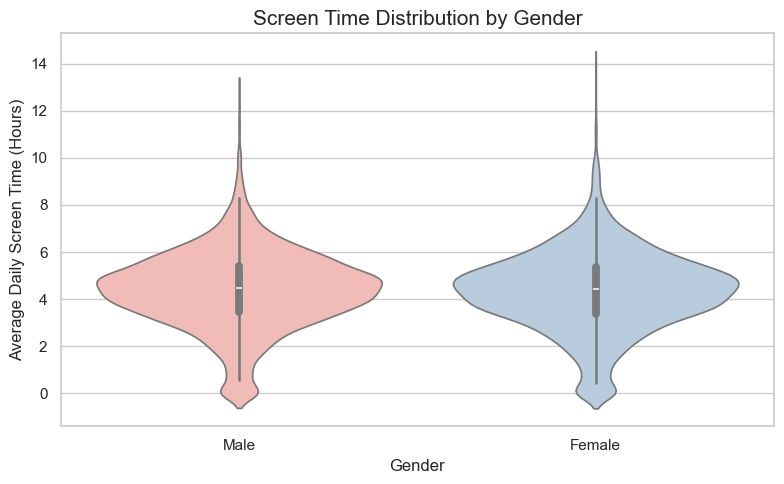

In [64]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Gender",
    y="Avg_Daily_Screen_Time_hr",
    palette="Pastel1",
    inner="box"
)

plt.title("Screen Time Distribution by Gender", fontsize=15)
plt.xlabel("Gender")
plt.ylabel("Average Daily Screen Time (Hours)")

plt.tight_layout()
plt.show()

**Insight:**
- Female participants exhibit slightly higher average screen time than Males, suggesting potential gender-based differences in digital engagement habits.

**Screen Time vs Age Band**

In [67]:
# Calculate Mean Screen Time for Each Age Band
age_mean = df.groupby("Age_Band")["Avg_Daily_Screen_Time_hr"].mean().reset_index()

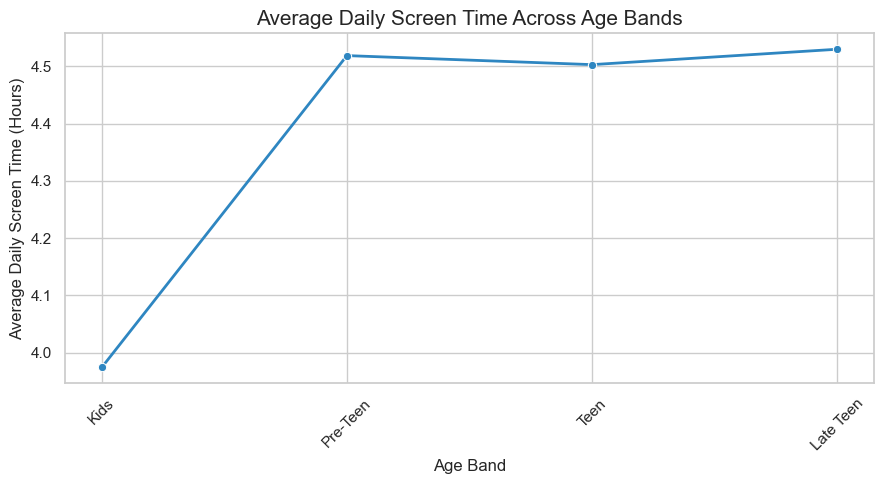

In [68]:
sns.set_style("whitegrid")

age_mean = df.groupby("Age_Band")["Avg_Daily_Screen_Time_hr"].mean().reset_index()

plt.figure(figsize=(9,5))

sns.lineplot(
    data=age_mean,
    x="Age_Band",
    y="Avg_Daily_Screen_Time_hr",
    marker="o",
    linewidth=2,
    color="#2E86C1"
)

plt.title("Average Daily Screen Time Across Age Bands", fontsize=15)
plt.xlabel("Age Band")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Insights:**
- As age increases → screen time increases.
- Teenagers spend more time than younger kids.
- So, The older the child, the higher the digital exposure.

**Screen Time by Location & Gender**

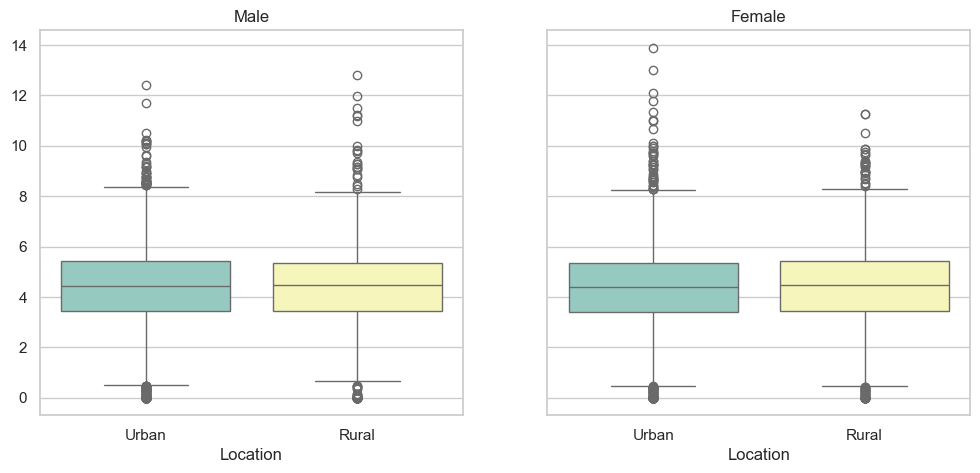

In [71]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

genders = df["Gender"].unique()

for i, gender in enumerate(genders):
    sns.boxplot(
        data=df[df["Gender"] == gender],
        x="Urban_or_Rural",
        y="Avg_Daily_Screen_Time_hr",
        palette="Set3",
        ax=axes[i]
    )
    axes[i].set_title(f"{gender}")
    axes[i].set_xlabel("Location")
    axes[i].set_ylabel("")

**insight:**
- Very minimal difference between urban and rural children.

**Age Band vs Engagement Risk Level**

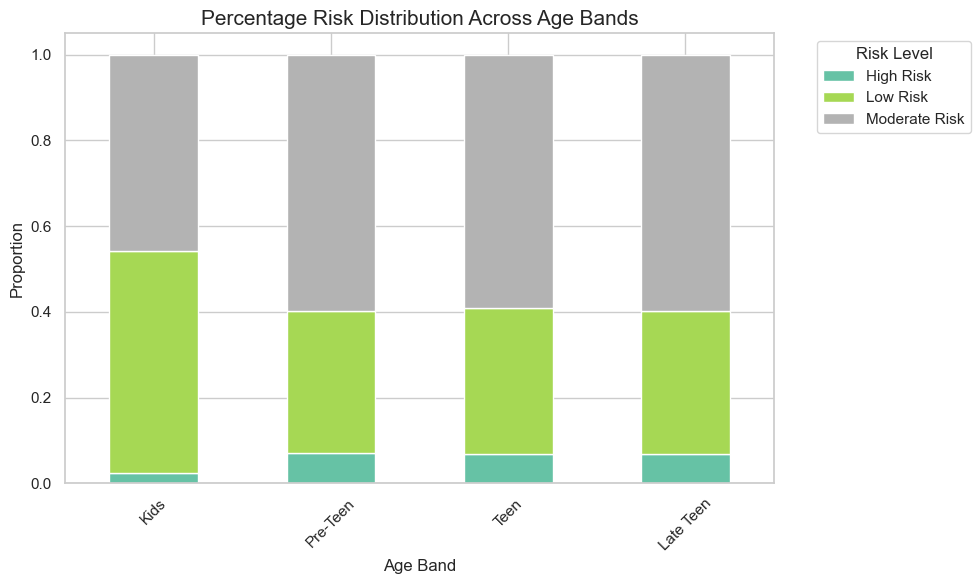

In [74]:
stack_data_pct = pd.crosstab(
    df['Age_Band'],
    df['Engagement_Risk_Level'],
    normalize='index'
)

# Plot
stack_data_pct.plot(
    kind='bar',
    stacked=True,
    colormap='Set2',
    figsize=(10,6)
)

plt.title("Percentage Risk Distribution Across Age Bands", fontsize=15)
plt.xlabel("Age Band")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Risk Level", bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

**Insigh:**
- Moderate risk children are the largest group in all age bands, while high-risk cases are fewer but present in every age group.

**Age vs Screen Time**

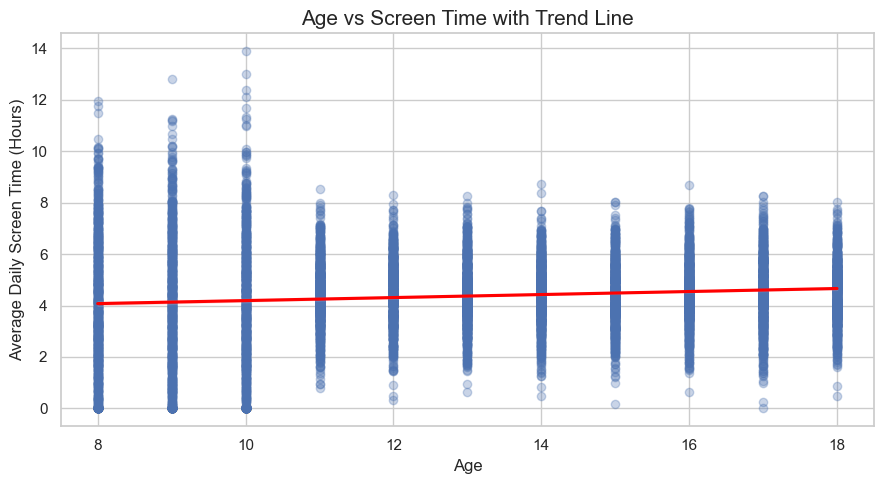

In [77]:
sns.set_style("whitegrid")
plt.figure(figsize=(9,5))

sns.regplot(
    data=df,
    x="Age",
    y="Avg_Daily_Screen_Time_hr",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Age vs Screen Time with Trend Line", fontsize=15)
plt.xlabel("Age")
plt.ylabel("Average Daily Screen Time (Hours)")

plt.tight_layout()
plt.show()

**Screen Time by Primary Device**

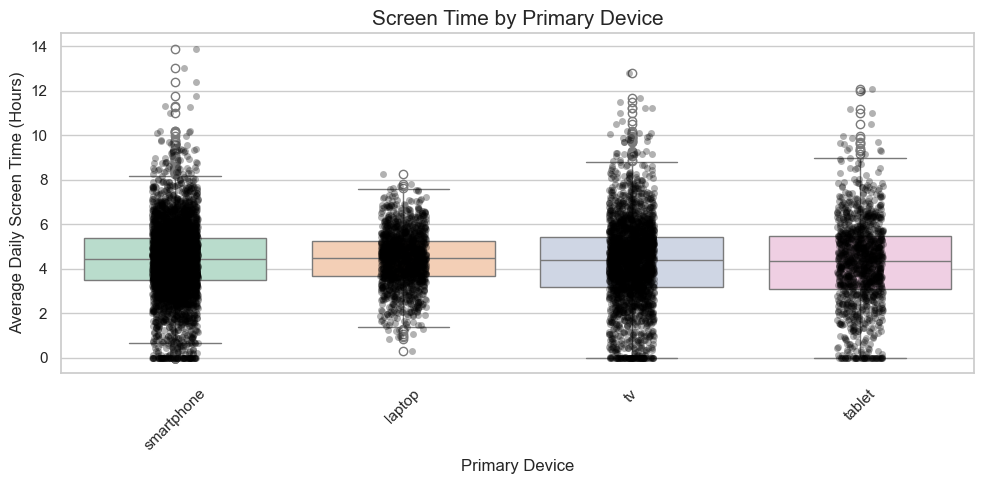

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Primary_Device",
    y="Avg_Daily_Screen_Time_hr",
    palette="Pastel2"
)

sns.stripplot(
    data=df,
    x="Primary_Device",
    y="Avg_Daily_Screen_Time_hr",
    color="black",
    alpha=0.3,
    jitter=True
)

plt.title("Screen Time by Primary Device", fontsize=15)
plt.xlabel("Primary Device")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Usage Purpose by Age Band**

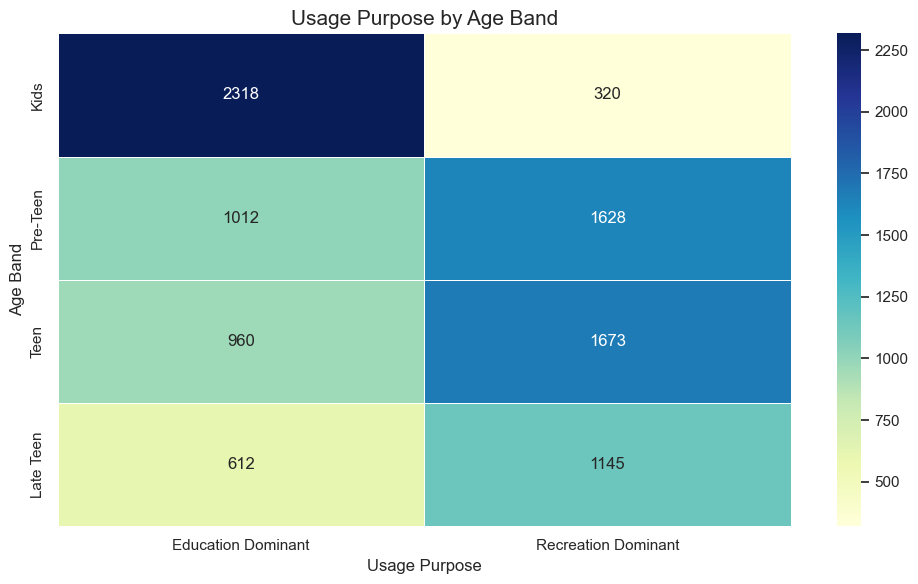

In [81]:
heat_data = pd.crosstab(
    df["Age_Band"],
    df["Usage_Purpose_Type"]
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heat_data,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Usage Purpose by Age Band", fontsize=15)
plt.xlabel("Usage Purpose")
plt.ylabel("Age Band")

plt.tight_layout()
plt.show()

**Device Access Distribution by Age Band**

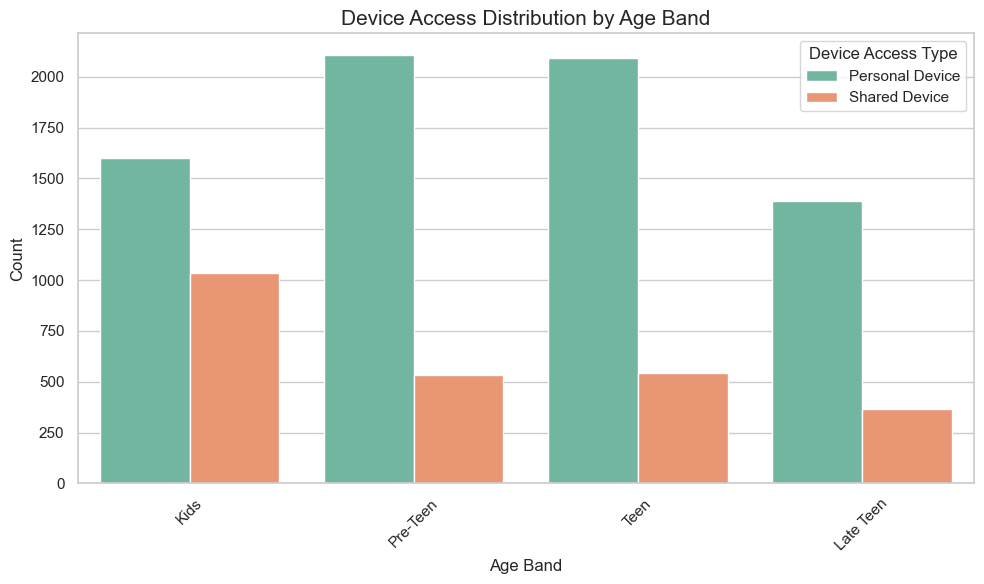

In [83]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Age_Band",
    hue="Device_Access_Type",
    palette="Set2"
)

plt.title("Device Access Distribution by Age Band", fontsize=15)
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.legend(title="Device Access Type")
plt.tight_layout()
plt.show()

**Screen Time Level Funnel Distribution**

<Figure size 1000x600 with 0 Axes>

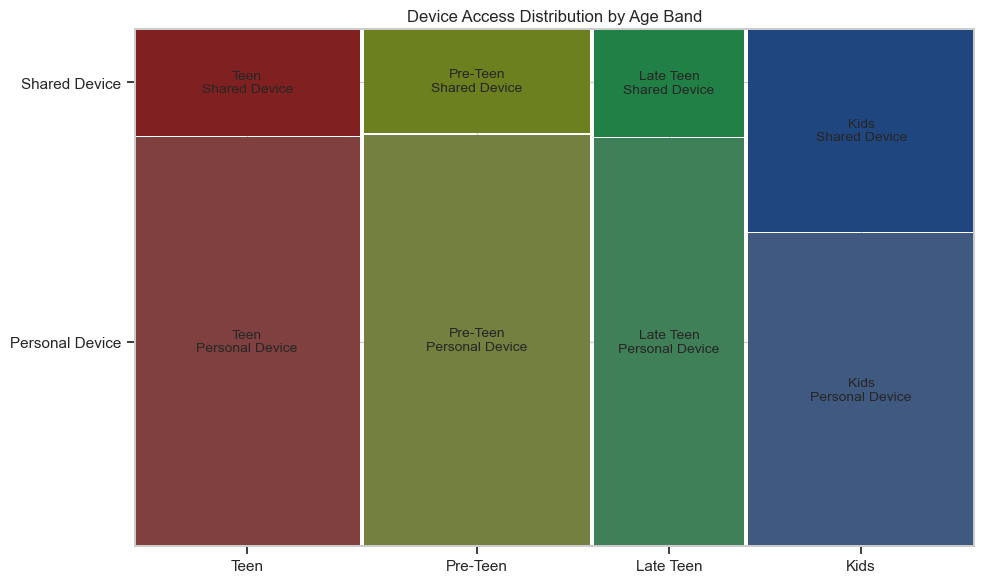

In [85]:
from statsmodels.graphics.mosaicplot import mosaic

plt.figure(figsize=(10,6))

mosaic(
    df,
    ['Age_Band', 'Device_Access_Type'],
    title="Device Access Distribution by Age Band"
)

plt.tight_layout()
plt.show()

**Age Band vs Multiple Metrics**

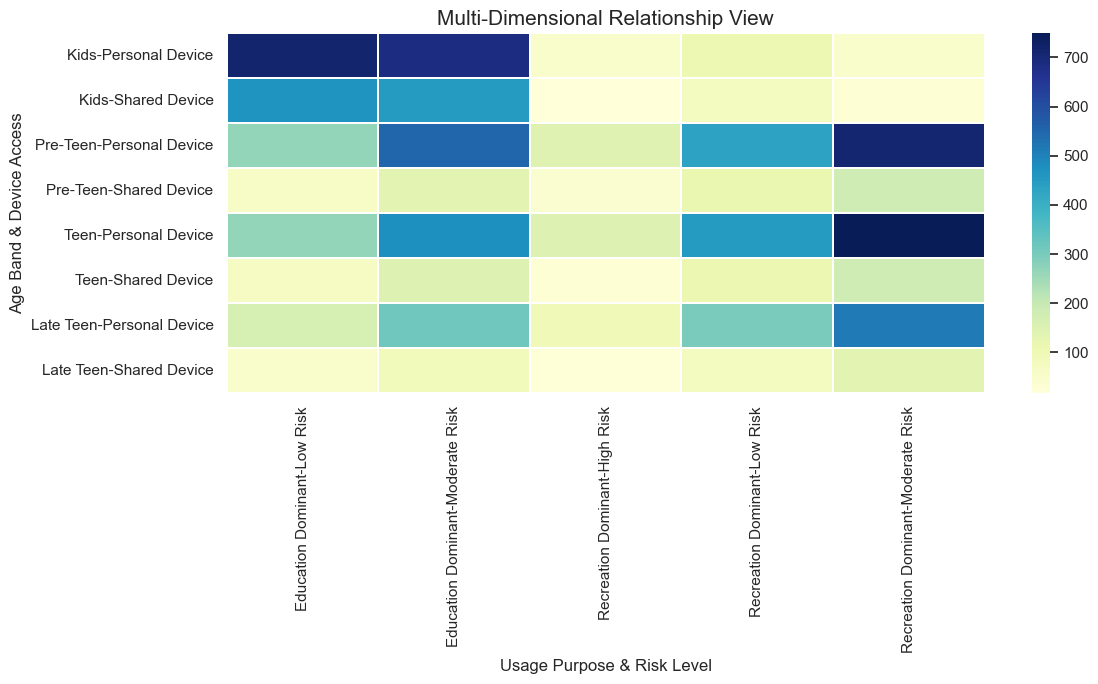

In [87]:
multi_data = pd.crosstab(
    [df["Age_Band"], df["Device_Access_Type"]],
    [df["Usage_Purpose_Type"], df["Engagement_Risk_Level"]]
)

plt.figure(figsize=(12,7))

sns.heatmap(
    multi_data,
    cmap="YlGnBu",
    linewidths=0.3
)

plt.title("Multi-Dimensional Relationship View", fontsize=15)
plt.xlabel("Usage Purpose & Risk Level")
plt.ylabel("Age Band & Device Access")

plt.tight_layout()
plt.show()

**Screen Time vs Location**

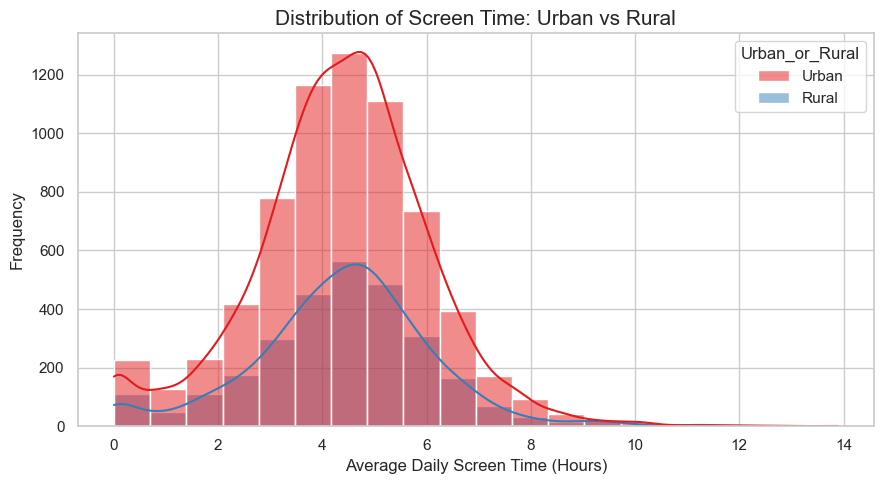

In [89]:
sns.set_style("whitegrid")
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="Avg_Daily_Screen_Time_hr",
    hue="Urban_or_Rural",
    bins=20,
    kde=True,
    alpha=0.5,
    palette="Set1"
)

plt.title("Distribution of Screen Time: Urban vs Rural", fontsize=15)
plt.xlabel("Average Daily Screen Time (Hours)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Screen Time vs Health Impact flag**

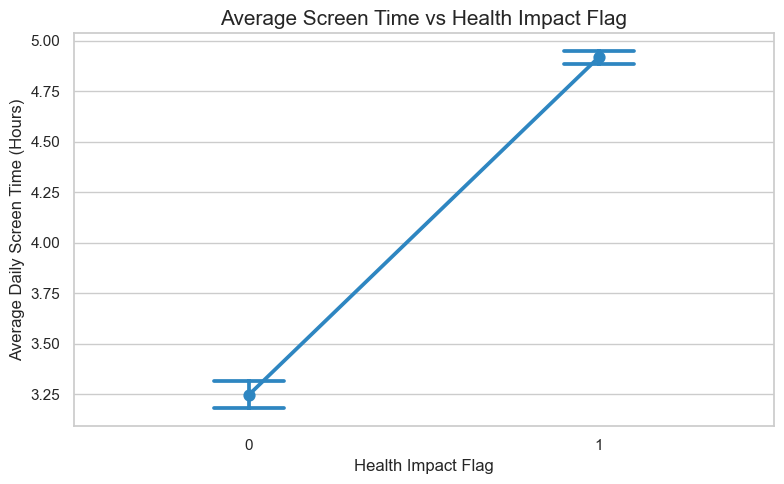

In [91]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.pointplot(
    data=df,
    x="Health_Impact_Flag",
    y="Avg_Daily_Screen_Time_hr",
    color="#2E86C1",
    capsize=0.2
)

plt.title("Average Screen Time vs Health Impact Flag", fontsize=15)
plt.xlabel("Health Impact Flag")
plt.ylabel("Average Daily Screen Time (Hours)")

plt.tight_layout()
plt.show()

**Primary Device by Age Band**

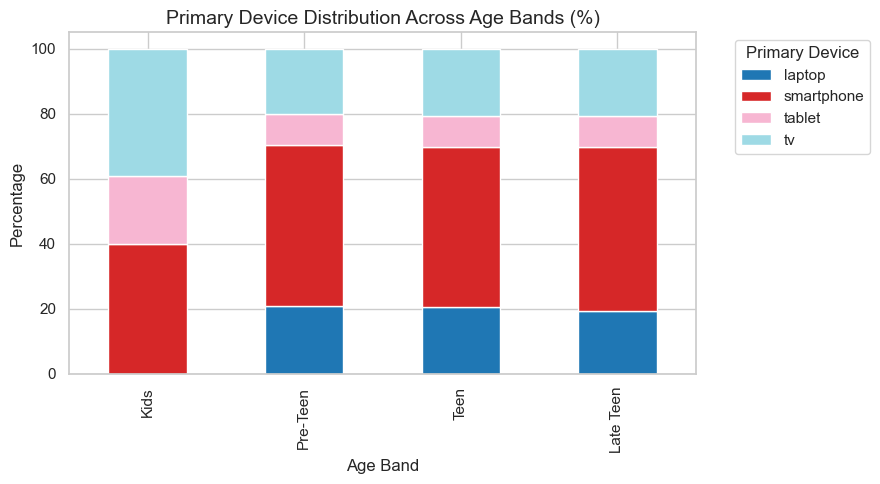

In [93]:
device_age_pct = pd.crosstab(
    df['Age_Band'],
    df['Primary_Device'],
    normalize='index'
) * 100

# Plot
device_age_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(9,5),
    colormap='tab20'
)

plt.title("Primary Device Distribution Across Age Bands (%)", fontsize=14)
plt.xlabel("Age Band")
plt.ylabel("Percentage")
plt.legend(title="Primary Device", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

**Primary Device by Location**

In [95]:
device_location = (
    df.groupby(['Urban_or_Rural', 'Primary_Device'])
      .size()
      .reset_index(name='count')
)

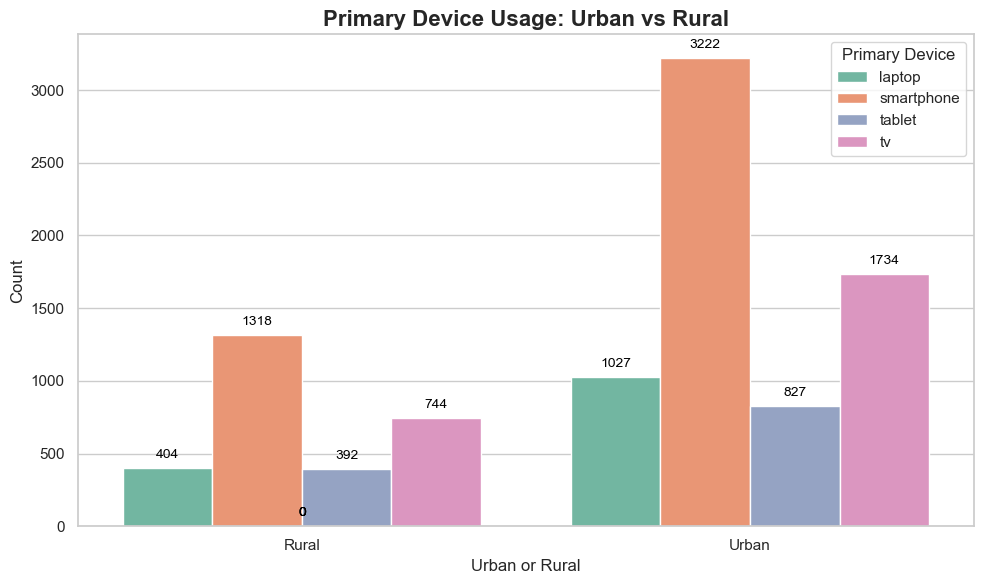

In [96]:
# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")
palette = sns.color_palette("Set2")  # soft, attractive colors

# Create the grouped bar chart
plt.figure(figsize=(10,6))
bar_plot = sns.barplot(
    data=device_location,
    x='Urban_or_Rural',
    y='count',
    hue='Primary_Device',
    palette=palette
)

# Add labels on top of bars
for p in bar_plot.patches:
    bar_plot.annotate(
        format(p.get_height(), '.0f'), 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10,
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Title and labels
plt.title('Primary Device Usage: Urban vs Rural', fontsize=16, weight='bold')
plt.xlabel('Urban or Rural', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Primary Device')

# Improve layout
plt.tight_layout()
plt.show()

**Educational_to_Recreational_Ratio vs avg daily Screen time**

In [98]:
# scatter + density + regression plot

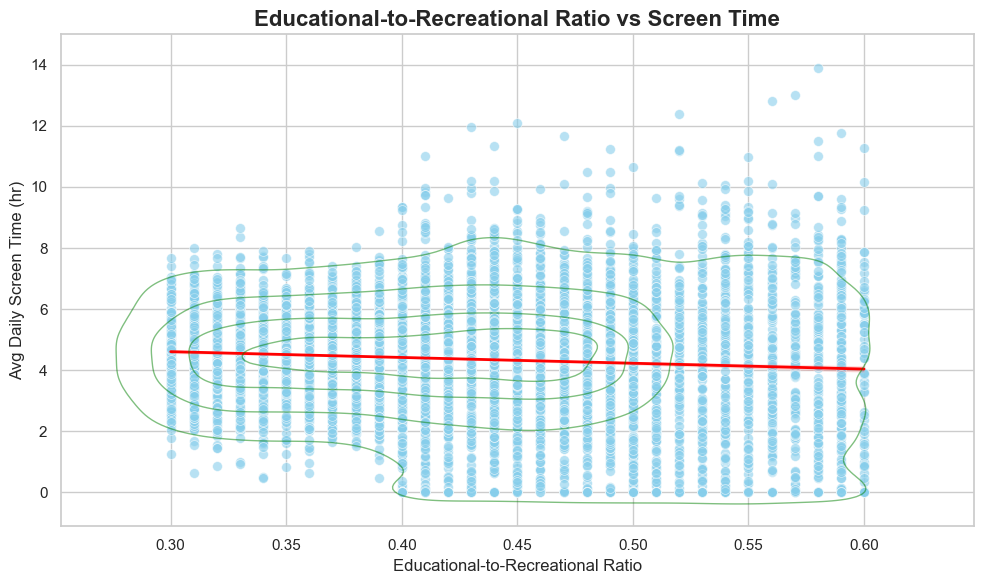

In [99]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

# 1. Scatter plot with transparency for density
sns.scatterplot(
    data=df,
    x='Educational_to_Recreational_Ratio',
    y='Avg_Daily_Screen_Time_hr',
    alpha=0.6,
    s=50,
    color='skyblue'
)

# 2. Regression line
sns.regplot(
    data=df,
    x='Educational_to_Recreational_Ratio',
    y='Avg_Daily_Screen_Time_hr',
    scatter=False,  # only show regression line
    line_kws={'color':'red', 'linewidth':2}
)

# 3. Optional: add a 2D density (contour) to show clustering
sns.kdeplot(
    data=df,
    x='Educational_to_Recreational_Ratio',
    y='Avg_Daily_Screen_Time_hr',
    levels=5,  # number of contour levels
    color='green',
    linewidths=1,
    alpha=0.5
)

plt.title('Educational-to-Recreational Ratio vs Screen Time', fontsize=16, weight='bold')
plt.xlabel('Educational-to-Recreational Ratio', fontsize=12)
plt.ylabel('Avg Daily Screen Time (hr)', fontsize=12)
plt.tight_layout()
plt.show()

**Count of Top Health Impact Combinations**

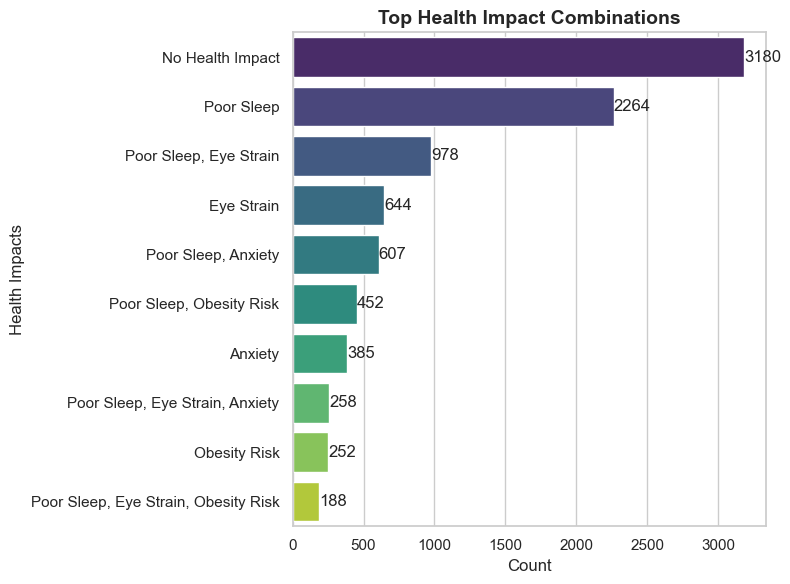

In [101]:
top_health = df['Health_Impacts'].value_counts().head(10).reset_index()
top_health.columns = ['Health_Impacts', 'count']

# Set style and palette
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))

# Horizontal bar plot
sns.barplot(
    data=top_health,
    x='count',
    y='Health_Impacts',
    palette='viridis'
)

# Add value labels on bars
for index, row in top_health.iterrows():
    plt.text(row['count'] + 0.5, index, row['count'], va='center')

plt.title('Top Health Impact Combinations', fontsize=14, weight='bold')
plt.xlabel('Count')
plt.ylabel('Health Impacts')
plt.tight_layout()
plt.show()

**Correlation Heatmap**

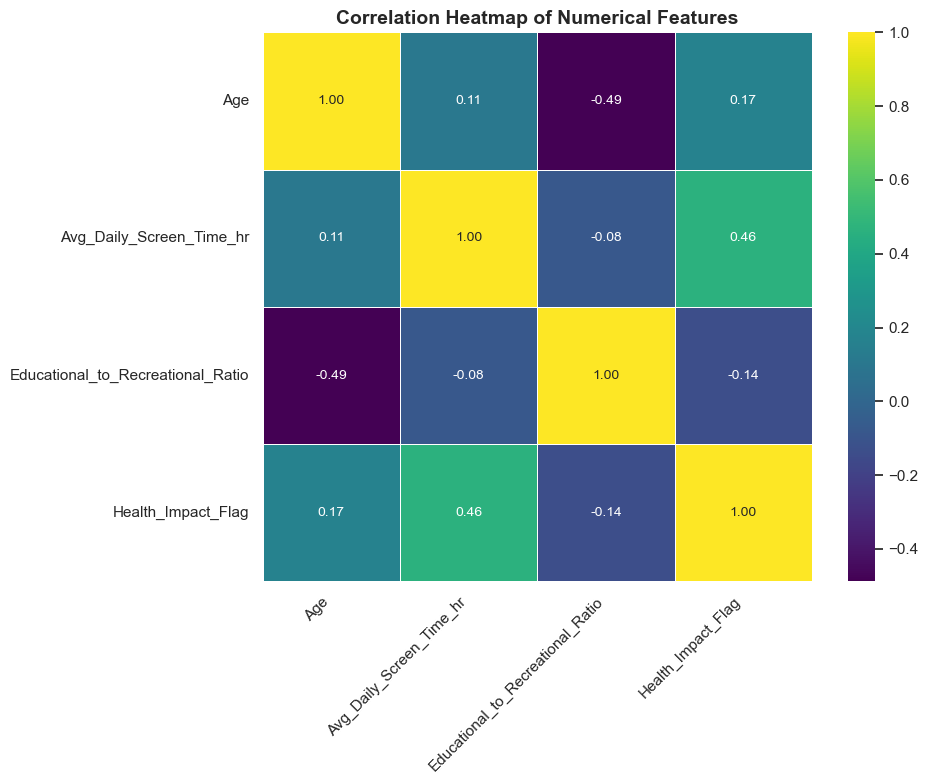

In [103]:
corr = df.select_dtypes(include=np.number).corr()

# Set style
sns.set_theme(style="white")

plt.figure(figsize=(10,8))

# Annotated heatmap
sns.heatmap( corr, annot=True,fmt=".2f",cmap='viridis',cbar=True,square=True,linewidths=0.5,           
    annot_kws={"size":10}     
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()